
# Sensitivity summary: raw vs imputed data

In [103]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import geopandas as gpd
import jenkspy


# Define country and parameters

In [104]:
# Select target country
country = 'Colombia'

if country == 'Argentina':
    country_short = 'ARG'
    country_code = 'AR'
elif country == 'Chile':
    country_short = 'CHL'
    country_code = 'CL'
elif country == 'Colombia':
    country_short = 'COL'
    country_code = 'CO'

wd = '/Users/carmen/Library/CloudStorage/OneDrive-TheUniversityofLiverpool/research/latin-mobility-covid'

# Keep these settings aligned with the main boxplot notebook
flows = 'outflows'
dist = True
adjust = True

# Keep the same month choices as in the existing notebook
months_by_grouping = {
    'population_density': ['2020-06', '2022-03'],
    'rdi': ['2020-05', '2022-03'],
}


# Load tile attributes and create classes

In [105]:
baseline_pop_imput = gpd.read_file(
    wd + '/data/outputs/' + country_short + '/grids-with-data/movcell-baseline-imput-pop-with-exo-var/movcell-baseline-imput-pop-with-exo-var.gpkg'
)

n_class_density = 5
breaks_density = jenkspy.jenks_breaks(
    baseline_pop_imput.dropna(subset=['density'])['density'],
    n_classes=n_class_density
)
breaks_density[0] = breaks_density[0] - 10 ** (-10)
baseline_pop_imput['class_density'] = pd.cut(
    baseline_pop_imput['density'],
    bins=breaks_density,
    labels=[i for i in range(n_class_density)]
)
baseline_pop_imput['class_density'] = pd.to_numeric(baseline_pop_imput['class_density'])

n_class_rdi = 3
breaks_rdi = jenkspy.jenks_breaks(
    baseline_pop_imput.dropna(subset=['rdi'])['rdi'],
    n_classes=n_class_rdi
)
breaks_rdi[0] = breaks_rdi[0] - 10 ** (-10)
baseline_pop_imput['class_rdi'] = pd.cut(
    baseline_pop_imput['rdi'],
    bins=breaks_rdi,
    labels=[i for i in range(n_class_rdi)]
)
baseline_pop_imput['class_rdi'] = pd.to_numeric(baseline_pop_imput['class_rdi'])

df_pop_evo = pd.read_csv(
    wd + '/data/outputs/' + country_short + '/evo/pop_evo_movcell.csv'
)
df_pop_evo = df_pop_evo.loc[:, ~df_pop_evo.columns.astype(str).str.startswith('Unnamed')]


# Helper functions

In [114]:
def drop_unnamed(df):
    return df.loc[:, ~df.columns.astype(str).str.startswith('Unnamed')]


def load_flows(raw_flag):
    dist_suffix = '_dist' if dist else ''
    raw_suffix = '_raw' if raw_flag else ''
    adjust_suffix = '' if raw_flag else ('_adjust' if adjust else '')

    df_flows = pd.read_csv(
        wd + '/data/outputs/' + country_short + '/mov-analysis/' + flows + dist_suffix + raw_suffix + adjust_suffix + '.csv'
    )
    df_flows_baseline = pd.read_csv(
        wd + '/data/outputs/' + country_short + '/mov-analysis/' + flows + '_baseline' + dist_suffix + raw_suffix + '.csv'
    )

    return drop_unnamed(df_flows), drop_unnamed(df_flows_baseline)


def apply_temporal_adjustment(df_flows):
    df_adjusted = df_flows.copy()

    id_col = 'O' if 'O' in df_adjusted.columns else ('D' if 'D' in df_adjusted.columns else None)
    start_idx = 1 if id_col is not None else 0

    shared_columns = [col for col in df_adjusted.columns[start_idx:] if col in df_pop_evo.columns]
    keep_columns = list(df_adjusted.columns[:start_idx]) + shared_columns
    df_adjusted = df_adjusted.loc[:, keep_columns].copy()

    median_total_pop = np.median([df_pop_evo[col].sum() for col in shared_columns])

    if id_col is not None:
        valid_ids = set(baseline_pop_imput.index)
        df_adjusted = df_adjusted[df_adjusted[id_col].isin(valid_ids)].reset_index(drop=True)

    for col in shared_columns:
        total_pop = df_pop_evo[col].sum()
        if pd.notna(median_total_pop) and pd.notna(total_pop) and total_pop != 0:
            df_adjusted[col] = df_adjusted[col] * median_total_pop / total_pop
        else:
            df_adjusted[col] = np.nan

    return df_adjusted


def get_mask(df_flows, indexes):
    if flows == 'movs':
        return df_flows['O'].isin(indexes) | df_flows['D'].isin(indexes)
    if flows == 'outflows':
        return df_flows['O'].isin(indexes)
    if flows == 'inflows':
        return df_flows['D'].isin(indexes)
    raise ValueError(f'Unsupported flow type: {flows}')


def summarise_pct_change(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return {
            'n_obs': 0,
            'mean_pct_change': np.nan,
            'median_pct_change': np.nan,
            'sd_pct_change': np.nan,
            'min_pct_change': np.nan,
            'p05_pct_change': np.nan,
            'p25_pct_change': np.nan,
            'p75_pct_change': np.nan,
            'p95_pct_change': np.nan,
            'max_pct_change': np.nan,
        }

    # Trim the bottom and top 15% before computing percentile-based summaries.
    trim_low = np.percentile(values, 15)
    trim_high = np.percentile(values, 85)
    trimmed_values = values[(values >= trim_low) & (values <= trim_high)]
    if len(trimmed_values) == 0:
        trimmed_values = values

    return {
        'n_obs': int(len(values)),
        'mean_pct_change': float(np.mean(values)),
        'median_pct_change': float(np.median(values)),
        'sd_pct_change': float(np.std(values)),
        'min_pct_change': float(np.min(values)),
        'p05_pct_change': float(np.percentile(trimmed_values, 5)),
        'p25_pct_change': float(np.percentile(trimmed_values, 25)),
        'p75_pct_change': float(np.percentile(trimmed_values, 75)),
        'p95_pct_change': float(np.percentile(trimmed_values, 95)),
        'max_pct_change': float(np.max(values)),
    }


def summarise_grouping(df_flows, df_flows_baseline, class_col, grouping_name, months, data_version):
    rows = []
    n_classes = int(baseline_pop_imput[class_col].dropna().nunique())

    for class_id in range(n_classes):
        indexes = set(baseline_pop_imput[baseline_pop_imput[class_col] == class_id].index)
        mask = get_mask(df_flows, indexes)

        df_group = df_flows[mask].reset_index(drop=True)
        df_group_baseline = df_flows_baseline[mask].reset_index(drop=True)

        for month in months:
            month_cols = [col for col in df_group.columns if month in col]
            month_cols_baseline = [col for col in df_group_baseline.columns if month in col]

            values = df_group.loc[:, month_cols].to_numpy().flatten()
            baseline_values = df_group_baseline.loc[:, month_cols_baseline].to_numpy().flatten()

            pct_change = (values - baseline_values) / baseline_values * 100
            stats = summarise_pct_change(pct_change)

            rows.append({
                'country': country_short,
                'flows': flows,
                'data_version': data_version,
                'grouping': grouping_name,
                'category': int(class_id + 1),
                'month': month,
                **stats,
            })

    return rows


# Build raw vs imputed comparison table

In [115]:
summary_rows = []

for raw_flag, data_version in [(False, 'imputed_adjusted'), (True, 'raw_adjusted_no_imputation')]:
    df_flows, df_flows_baseline = load_flows(raw_flag)

    if raw_flag:
        df_flows = apply_temporal_adjustment(df_flows)

    summary_rows.extend(
        summarise_grouping(
            df_flows,
            df_flows_baseline,
            class_col='class_density',
            grouping_name='population_density',
            months=months_by_grouping['population_density'],
            data_version=data_version,
        )
    )

    summary_rows.extend(
        summarise_grouping(
            df_flows,
            df_flows_baseline,
            class_col='class_rdi',
            grouping_name='rdi',
            months=months_by_grouping['rdi'],
            data_version=data_version,
        )
    )

df_summary = pd.DataFrame(summary_rows)
df_summary = df_summary.sort_values(['grouping', 'month', 'category', 'data_version']).reset_index(drop=True)

output_path = (
    wd
    + '/data/outputs/'
    + country_short
    + '/mov-analysis/boxplots-before-after-summary-raw-vs-imputed-r2.csv'
)
os.makedirs(os.path.dirname(output_path), exist_ok=True)
df_summary.to_csv(output_path, index=False)

print(output_path)
df_summary


/Users/carmen/Library/CloudStorage/OneDrive-TheUniversityofLiverpool/research/latin-mobility-covid/data/outputs/COL/mov-analysis/boxplots-before-after-summary-raw-vs-imputed-r2.csv


,country,flows,data_version,grouping,category,month,n_obs,mean_pct_change,median_pct_change,sd_pct_change,min_pct_change,p05_pct_change,p25_pct_change,p75_pct_change,p95_pct_change,max_pct_change
0,COL,outflows,imputed_adjusted,population_density,1,2020-06,56388,39.372098,11.255627,96.743951,-90.394736,-29.738116,-13.154302,47.238898,95.979862,1956.091574
1,COL,outflows,raw_adjusted_no_imputation,population_density,1,2020-06,13982,-21.000545,-24.051336,24.994489,-84.581571,-42.056398,-33.288336,-13.222770,-1.226099,155.599551
2,COL,outflows,imputed_adjusted,population_density,2,2020-06,4760,-34.274289,-37.368751,26.921450,-87.039218,-51.087772,-44.212730,-30.608397,-22.378448,319.747533
3,COL,outflows,raw_adjusted_no_imputation,population_density,2,2020-06,4418,-38.735130,-39.283627,17.310897,-84.935275,-52.342860,-45.895323,-32.961143,-27.016680,73.914668
4,COL,outflows,imputed_adjusted,population_density,3,2020-06,1170,-44.401041,-44.302319,14.985222,-82.892741,-56.728971,-51.918216,-37.924404,-31.766667,39.688550
5,COL,outflows,raw_adjusted_no_imputation,population_density,3,2020-06,1136,-44.231401,-44.094568,15.322210,-84.139864,-56.620679,-51.344098,-37.938261,-32.234623,22.479523
6,COL,outflows,imputed_adjusted,population_density,4,2020-06,570,-51.193834,-51.085197,13.326480,-85.838157,-63.238133,-57.079774,-43.793470,-38.325672,-20.120014
7,COL,outflows,raw_adjusted_no_imputation,population_density,4,2020-06,570,-51.389490,-51.197729,13.225389,-85.947651,-63.327294,-57.231236,-44.022098,-38.700592,-21.832465
8,COL,outflows,imputed_adjusted,population_density,5,2020-06,630,-57.837159,-57.853358,13.596650,-83.599619,-72.384046,-65.260617,-50.885939,-44.501364,-24.509001
9,COL,outflows,raw_adjusted_no_imputation,population_density,5,2020-06,630,-57.902293,-57.951432,13.568296,-83.570606,-72.581317,-65.271735,-51.050567,-44.644361,-24.322397


# Visualise raw vs imputed summary results

/Users/carmen/Library/CloudStorage/OneDrive-TheUniversityofLiverpool/research/latin-mobility-covid/plots/boxplots/COL_density_202006_raw-vs-imputed-summary-r2.pdf


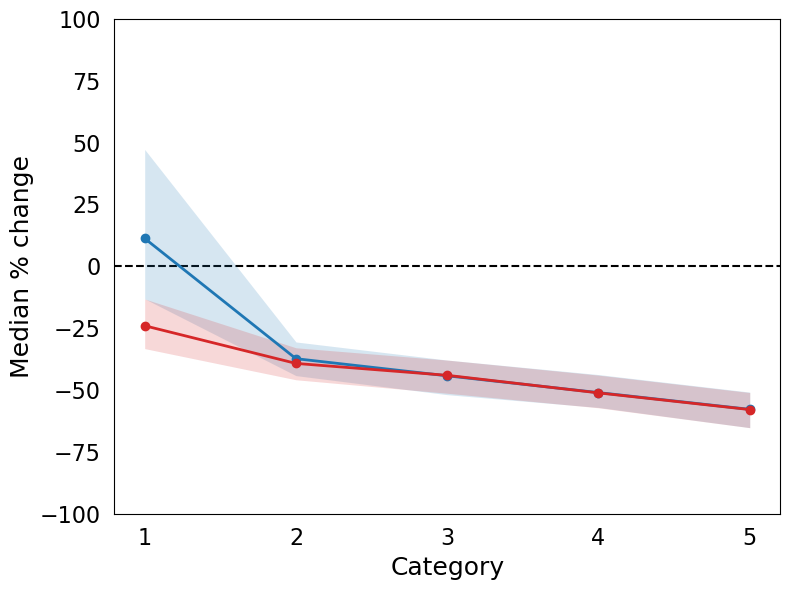

/Users/carmen/Library/CloudStorage/OneDrive-TheUniversityofLiverpool/research/latin-mobility-covid/plots/boxplots/COL_density_202203_raw-vs-imputed-summary-r2.pdf


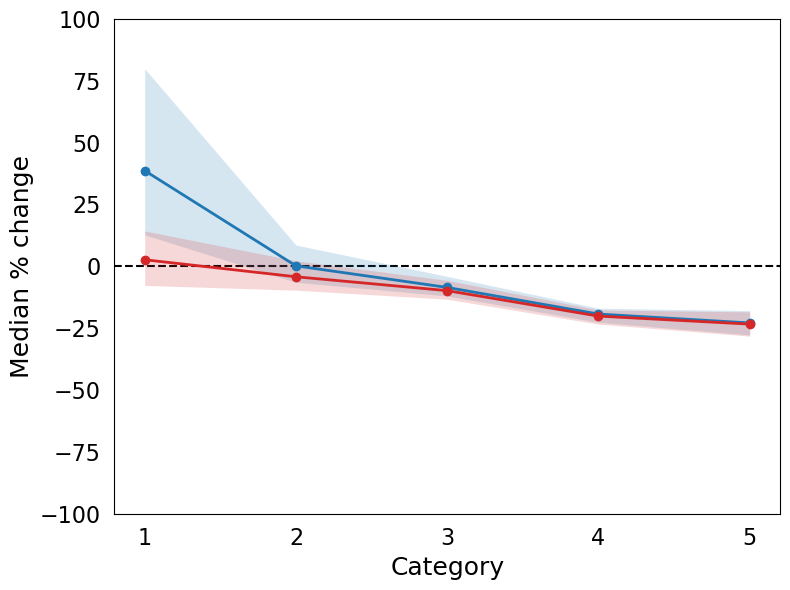

/Users/carmen/Library/CloudStorage/OneDrive-TheUniversityofLiverpool/research/latin-mobility-covid/plots/boxplots/COL_rdi_202005_raw-vs-imputed-summary-r2.pdf


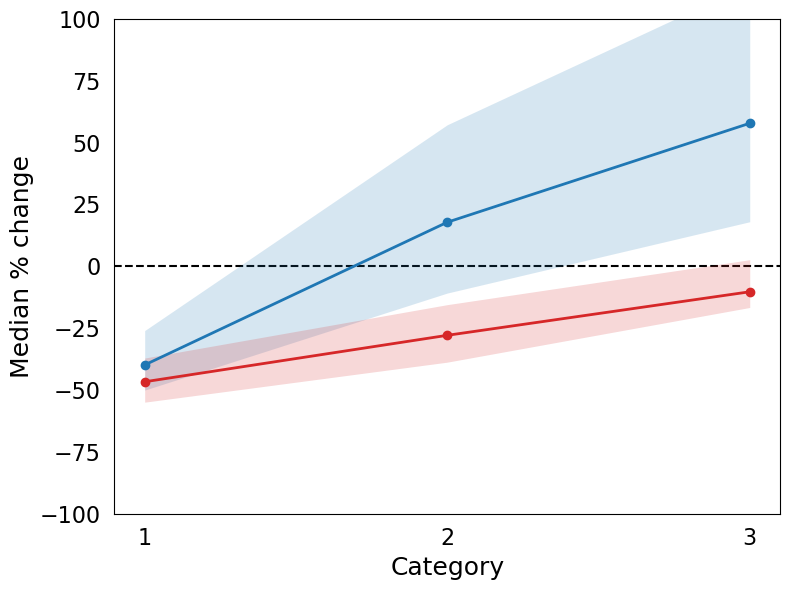

/Users/carmen/Library/CloudStorage/OneDrive-TheUniversityofLiverpool/research/latin-mobility-covid/plots/boxplots/COL_rdi_202203_raw-vs-imputed-summary-r2.pdf


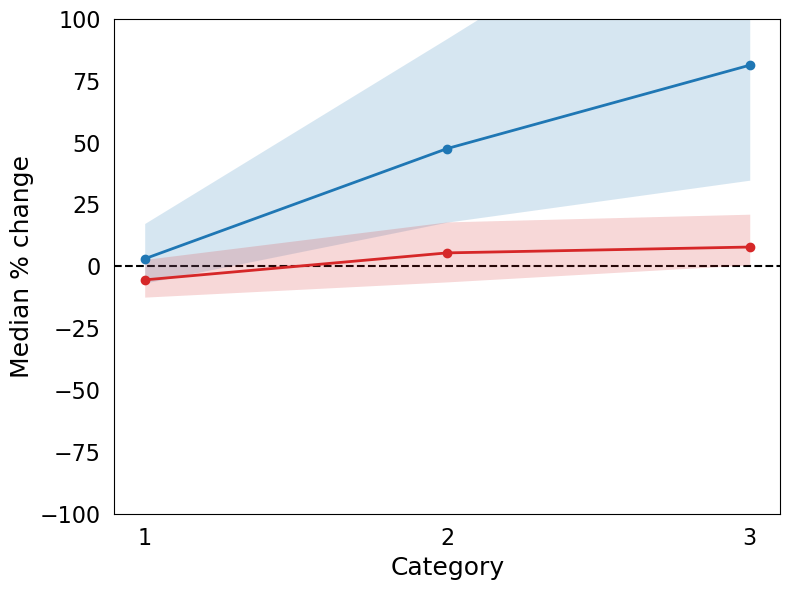

In [116]:
plot_specs = [
    ('population_density', '2020-06', 'Population density, Jun 2020'),
    ('population_density', '2022-03', 'Population density, Mar 2022'),
    ('rdi', '2020-05', 'RDI, May 2020'),
    ('rdi', '2022-03', 'RDI, Mar 2022'),
]

label_map = {
    'imputed_adjusted': 'Imputed/adjusted',
    'raw_adjusted_no_imputation': 'Raw/adjusted, no imputation',
}

color_map = {
    'imputed_adjusted': '#1f77b4',
    'raw_adjusted_no_imputation': '#d62728',
}

plot_dir = wd + '/plots/boxplots/'
os.makedirs(plot_dir, exist_ok=True)

for grouping, month, title in plot_specs:
    subset = df_summary[(df_summary['grouping'] == grouping) & (df_summary['month'] == month)].copy()
    fig, ax = plt.subplots(figsize=(8, 6), layout='tight')

    for data_version in ['imputed_adjusted', 'raw_adjusted_no_imputation']:
        data = subset[subset['data_version'] == data_version].sort_values('category')
        x = data['category'].to_numpy(dtype=float)
        y = data['median_pct_change'].to_numpy(dtype=float)
        y_low = data['p25_pct_change'].to_numpy(dtype=float)
        y_high = data['p75_pct_change'].to_numpy(dtype=float)

        ax.fill_between(
            x,
            y_low,
            y_high,
            color=color_map[data_version],
            alpha=0.18,
            linewidth=0,
        )
        ax.plot(
            x,
            y,
            marker='o',
            linewidth=2,
            markersize=6,
            label=label_map[data_version],
            color=color_map[data_version],
        )

    ax.axhline(0, color='black', linewidth=1.5, linestyle='--', zorder=0)
    ax.set_xlabel('Category', fontsize=18)
    ax.set_ylabel('Median % change', fontsize=18)
    ax.set_ylim(-100, 100)
    ax.set_xticks(sorted(subset['category'].unique()))
    ax.tick_params(axis='x', which='both', labelsize=16, pad=10, width=0, length=0, color='k')
    ax.tick_params(axis='y', which='both', labelsize=16, pad=10, width=0, length=0, color='k')

    file_grouping = grouping.replace('population_density', 'density')
    file_month = month.replace('-', '')
    plot_path = (
        plot_dir
        + country_short
        + '_'
        + file_grouping
        + '_'
        + file_month
        + '_raw-vs-imputed-summary-r2.pdf'
    )
    plt.savefig(plot_path, bbox_inches='tight')
    print(plot_path)
    plt.show()
